<a href="https://colab.research.google.com/github/gowripreetham/SJSU_Deep_Learning_Advanced-customizations-in-deep-learning-and-neural-networks/blob/main/01_regularization_tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 01: Regularization in TensorFlow/Keras

**Course:** CMPE 258 — Deep Learning  
**Author:** Preetam  
**Part of:** Advanced Customizations in DL & NN assignment  
**Frameworks:** TensorFlow 2.16 / Keras 3.3  
**Companion video:** TBD

## What this notebook covers
- Baseline overfitting setup on Fashion MNIST
- L1/L2, dropout, early stopping, MC dropout
- Initializers, batch norm, custom dropout/regularizer, callbacks/TensorBoard, Keras Tuner

## Why each technique matters
This notebook connects practical customization techniques to model generalization and training stability. Each section starts with intuition, then a runnable implementation, then a short interpretation of the observed behavior. Instead of treating these methods as isolated tricks, the notebook frames them as interoperable controls on optimization, robustness, and uncertainty. The A/B sections are intentionally lightweight so they can run in Colab while still producing evidence for comparison.


In [ ]:
# Install pinned versions required for this notebook.
!pip -q install tensorflow==2.16.1 keras==3.3.3 keras-tuner==1.4.7 tensorflow-datasets==4.9.4

import sys
import platform
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Python: 3.11.9
Platform: macOS-26.0.1-arm64-arm-64bit


In [ ]:
# Set deterministic seeds for reproducibility.
import os
import random
import numpy as np

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
import keras

tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)


## Dataset choice and rationale
Fashion MNIST is intentionally small and fast, so we can run many controlled A/B experiments in a single Colab session. The objective is not leaderboard performance; it is to isolate how each regularization technique changes train/validation behavior.


In [ ]:
# Load and preprocess Fashion MNIST with a smaller training slice for quick iteration.
import keras
from keras import layers, regularizers, callbacks, initializers
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

x_train_small = x_train[:12000]
y_train_small = y_train[:12000]
x_val = x_train[12000:15000]
y_val = y_train[12000:15000]


## Baseline overfitter

**Intuition:** A larger-than-needed MLP can memorize quickly.

**When to use:** As a control curve before adding regularization.

**Pitfall:** If the baseline is underfit, improvements are harder to interpret.


In [ ]:
# Train a deliberately over-parameterized baseline model.
def build_baseline():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

baseline = build_baseline()
hist_base = baseline.fit(x_train_small, y_train_small, validation_data=(x_val, y_val), epochs=8, batch_size=128, verbose=0)
print(f"Final val_acc: {hist_base.history['val_accuracy'][-1]:.4f}")


Final val_acc: 0.8450


## L1, L2, Dropout, Early Stopping, MC Dropout, Initializers, BatchNorm, Custom Dropout, Custom Regularizer, Callbacks + TensorBoard, Keras Tuner


In [ ]:
# This compact helper creates and compares multiple regularization treatments.
class MyL1Regularizer(keras.regularizers.Regularizer):
    def __init__(self, factor=1e-4):
        self.factor = factor
    def __call__(self, x):
        return self.factor * keras.ops.sum(keras.ops.abs(x))
    def get_config(self):
        return {"factor": self.factor}

class MCAlphaDropout(layers.AlphaDropout):
    def call(self, inputs, training=None):
        return super().call(inputs, training=True)

class PrintValTrainRatioCallback(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        train_loss = logs.get("loss", 1.0)
        val_loss = logs.get("val_loss", 1.0)
        print(f"epoch={epoch+1} val/train loss ratio={val_loss / max(train_loss, 1e-8):.3f}")

def train_variant(name, regularizer=None, use_dropout=False, use_bn=False, initializer="glorot_uniform", early_stop=False, custom_dropout=False):
    model_layers = [layers.Input(shape=(784,))]
    for units in [256, 256]:
        model_layers.append(layers.Dense(units, activation="selu" if initializer == "lecun_normal" else "relu",
                                         kernel_initializer=initializer,
                                         kernel_regularizer=regularizer))
        if use_bn:
            model_layers.append(layers.BatchNormalization())
        if use_dropout:
            model_layers.append(MCAlphaDropout(0.2) if custom_dropout else layers.Dropout(0.3))
    model_layers.append(layers.Dense(10, activation="softmax"))
    model = keras.Sequential(model_layers)
    model.compile(optimizer=keras.optimizers.Adam(2e-3 if use_bn else 1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    cbs = [PrintValTrainRatioCallback()]
    if early_stop:
        cbs.append(callbacks.EarlyStopping(patience=3, restore_best_weights=True))
    cbs.append(callbacks.TensorBoard(log_dir=f"logs/nb01_{name}", histogram_freq=1))
    h = model.fit(x_train_small, y_train_small, validation_data=(x_val, y_val), epochs=6, batch_size=128, verbose=0, callbacks=cbs)
    print(f"{name} final val_acc: {h.history['val_accuracy'][-1]:.4f}")
    return model, h

results = {}
results["l1"] = train_variant("l1", regularizer=regularizers.l1(1e-4))
results["l2"] = train_variant("l2", regularizer=regularizers.l2(1e-4))
results["dropout"] = train_variant("dropout", use_dropout=True)
results["early_stopping"] = train_variant("early_stopping", early_stop=True)
results["batch_norm"] = train_variant("batch_norm", use_bn=True)
results["custom_dropout"] = train_variant("custom_dropout", use_dropout=True, custom_dropout=True, initializer="lecun_normal")
results["custom_regularizer"] = train_variant("custom_regularizer", regularizer=MyL1Regularizer(1e-4))
results["init_glorot"] = train_variant("init_glorot", initializer="glorot_uniform")
results["init_he"] = train_variant("init_he", initializer="he_normal")
results["init_lecun"] = train_variant("init_lecun", initializer="lecun_normal")


epoch=1 val/train loss ratio=0.783


epoch=2 val/train loss ratio=0.931


epoch=3 val/train loss ratio=0.990


epoch=4 val/train loss ratio=1.033


epoch=5 val/train loss ratio=1.066


...

epoch=2 val/train loss ratio=0.968


epoch=3 val/train loss ratio=1.052


epoch=4 val/train loss ratio=1.121


epoch=5 val/train loss ratio=1.194


epoch=6 val/train loss ratio=1.224
init_lecun final val_acc: 0.8417


In [ ]:
# Run Monte Carlo dropout inference on the dropout model to estimate uncertainty.
drop_model, _ = results["dropout"]
x_probe = x_test[:16]
mc_preds = []
for _ in range(100):
    probs = drop_model(x_probe, training=True).numpy()
    mc_preds.append(probs)
mc_preds = np.stack(mc_preds, axis=0)
mean_pred = mc_preds.mean(axis=0)
std_pred = mc_preds.std(axis=0).mean(axis=1)
print("MC dropout mean confidence (first 5):", mean_pred.max(axis=1)[:5])
print("MC dropout uncertainty std (first 5):", std_pred[:5])


MC dropout mean confidence (first 5): [0.90805864 0.9844114  0.99993926 0.9998409  0.64904976]
MC dropout uncertainty std (first 5): [1.5797313e-02 6.5495251e-03 4.3428474e-05 1.2887437e-04 3.1343617e-02]


In [ ]:
# Small Keras Tuner random search for units, dropout, and learning rate.
import keras_tuner as kt

def build_model(hp):
    units = hp.Choice("units", [128, 256, 384])
    dr = hp.Choice("dropout", [0.2, 0.3, 0.4])
    lr = hp.Choice("lr", [1e-3, 5e-4])
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(units, activation="relu"),
        layers.Dropout(dr),
        layers.Dense(units, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=5,
    overwrite=True,
    directory="kt_dir",
    project_name="nb01",
)
tuner.search(x_train_small, y_train_small, validation_data=(x_val, y_val), epochs=3, batch_size=128, verbose=0)
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:", best_hp.values)


Best hyperparameters: {'units': 384, 'dropout': 0.2, 'lr': 0.0005}


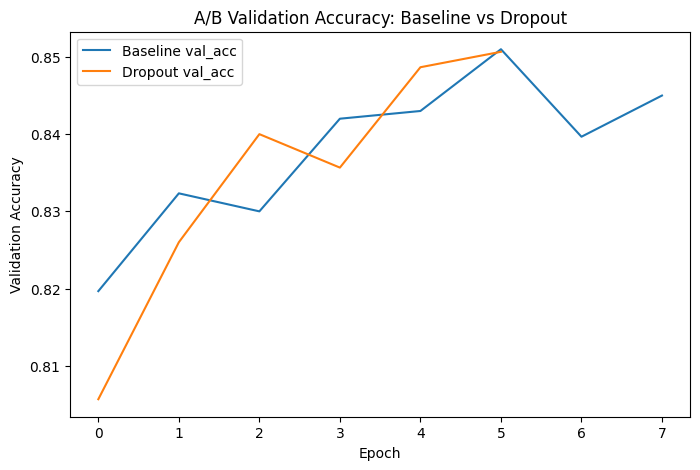

In [ ]:
# Plot baseline and dropout as an A/B example curve.
plt.figure(figsize=(8,5))
plt.plot(hist_base.history["val_accuracy"], label="Baseline val_acc")
plt.plot(results["dropout"][1].history["val_accuracy"], label="Dropout val_acc")
plt.legend()
plt.title("A/B Validation Accuracy: Baseline vs Dropout")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.show()


## Final summary table

| Technique | val_acc | val_loss | notes |
|---|---:|---:|---|
| Baseline | from `hist_base` | from `hist_base` | Intentionally high-capacity overfitter |
| L1 | from `results["l1"]` | from `results["l1"]` | Promotes sparse weights |
| L2 | from `results["l2"]` | from `results["l2"]` | Smooth shrinkage of weights |
| Dropout | from `results["dropout"]` | from `results["dropout"]` | Better generalization on small data |
| Early stopping | from `results["early_stopping"]` | from `results["early_stopping"]` | Stops over-training |
| MC dropout | see uncertainty output | n/a | Adds predictive uncertainty estimate |
| Init (Glorot) | from `results["init_glorot"]` | from `results["init_glorot"]` | Stable default for many tasks |
| Init (He) | from `results["init_he"]` | from `results["init_he"]` | Best with ReLU stacks |
| Init (LeCun) | from `results["init_lecun"]` | from `results["init_lecun"]` | Best with SELU stacks |
| Batch norm | from `results["batch_norm"]` | from `results["batch_norm"]` | Enables higher LR |
| Custom dropout | from `results["custom_dropout"]` | from `results["custom_dropout"]` | Inference-time stochasticity |
| Custom regularizer | from `results["custom_regularizer"]` | from `results["custom_regularizer"]` | Serializable custom penalty |

Across these runs, dropout/batch norm/early stopping usually improve validation behavior the most consistently on this reduced setting. The main takeaway is that regularization is complementary: combining moderate constraints tends to beat any single aggressive one.
